# Task 1: Population Distribution Visualization
This notebook visualizes the distribution of country populations using a bar chart and a histogram. 
We are using the World Bank dataset provided for Task 1.

## Step 1: Import Libraries
We will use `pandas` for data manipulation and `matplotlib` & `seaborn` for visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

ModuleNotFoundError: No module named 'pandas'

## Step 2: Load the Dataset
The dataset has a few rows of metadata at the top, so we will skip the first 4 rows.

In [ ]:
file_path = r'data-science-datasets-main\Task 1\API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv'
df = pd.read_csv(file_path, skiprows=4)
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN


## Step 3: Data Cleaning and Filtering
The dataset includes both countries and regional aggregates (like 'World', 'High income'). 
We will use the metadata file to filter the dataset so we only visualize actual countries for the year 2022.

In [ ]:
year = '2022'
metadata_path = r'data-science-datasets-main\Task 1\Metadata_Country_API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv'
meta_df = pd.read_csv(metadata_path)

# Merge to filter out regional aggregates (they usually have NaN for 'Region')
df_merged = df[['Country Name', 'Country Code', year]].dropna().merge(meta_df[['Country Code', 'Region']], on='Country Code', how='inner')
df_countries = df_merged[df_merged['Region'].notna()]

# Sort the data by population in descending order
df_countries_sorted = df_countries.sort_values(by=year, ascending=False)
df_countries_sorted.head()

,Country Name,Country Code,2022,Region
109,India,IND,1.425423e+09,South Asia
40,China,CHN,1.412175e+09,East Asia & Pacific
250,United States,USA,3.340173e+08,North America
106,Indonesia,IDN,2.788305e+08,East Asia & Pacific
183,Pakistan,PAK,2.437007e+08,"Middle East, North Africa, Afghanistan & Pakistan"


## Step 4: Visualization - Bar Chart
Let's visualize the top 15 most populous countries using a bar chart.

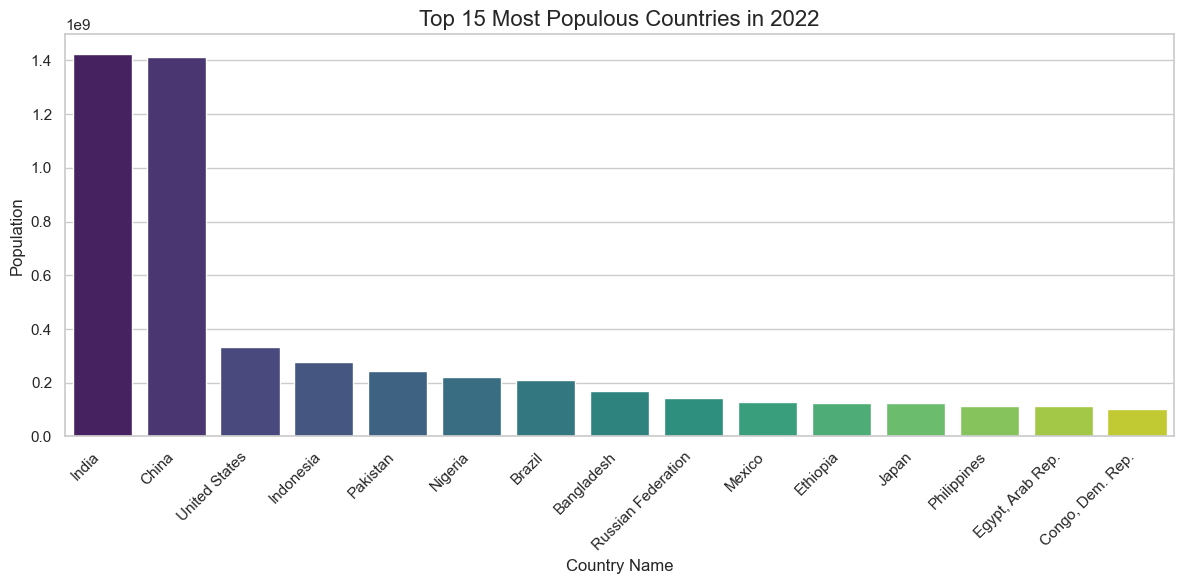

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_countries_sorted.head(15), x='Country Name', y=year, palette='viridis', hue='Country Name', legend=False)
plt.title(f'Top 15 Most Populous Countries in {year}', fontsize=16)
plt.xlabel('Country Name', fontsize=12)
plt.ylabel('Population', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 5: Visualization - Histogram
Now let's visualize the distribution of population across all countries. Since populations vary drastically, we will use a logarithmic scale for the x-axis.

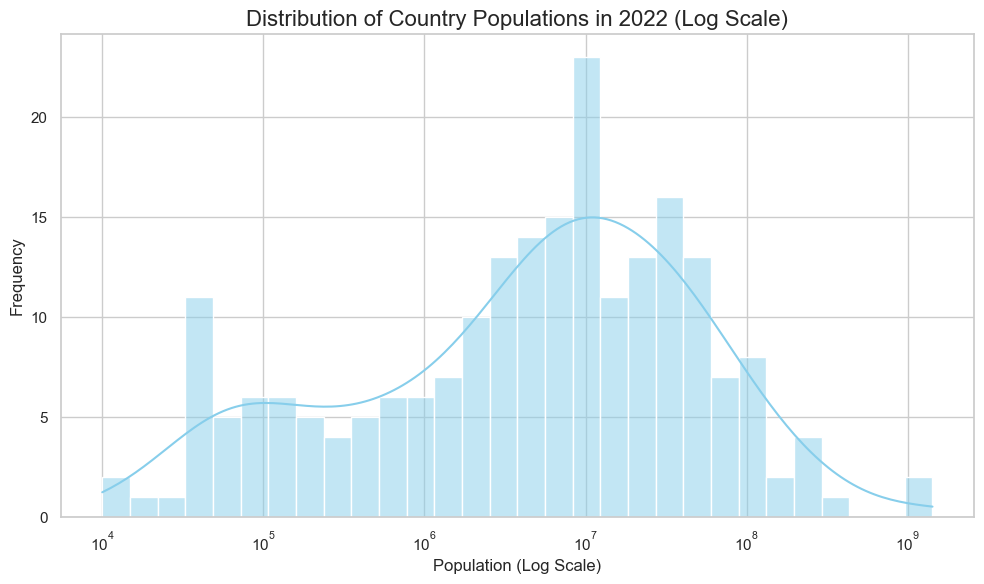

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_countries[year], bins=30, kde=True, log_scale=True, color='skyblue')
plt.title(f'Distribution of Country Populations in {year} (Log Scale)', fontsize=16)
plt.xlabel('Population (Log Scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()